SVM Kernels Indepth intuition and Practical Guide

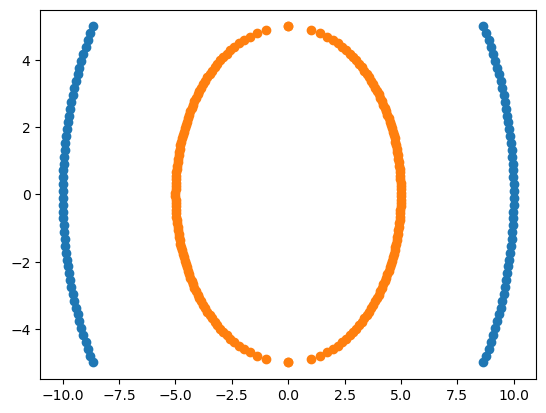

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn import svm

x = np.linspace(-5.0, 5.0)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y,-y])
x = np.hstack([x,-x])

x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(5**2-x1**2)
x1 = np.hstack([x1,-x1])
y1 = np.hstack([y1,-y1])

plt.scatter(y,x)
plt.scatter(y1,x1)
plt.show()

In [4]:
np.vstack([y,x]).T
np.vstack([y1,x1]).T

array([[ 0.        , -5.        ],
       [ 0.99994898, -4.8989899 ],
       [ 1.40690791, -4.7979798 ],
       [ 1.71419826, -4.6969697 ],
       [ 1.96904936, -4.5959596 ],
       [ 2.18984681, -4.49494949],
       [ 2.38606299, -4.39393939],
       [ 2.563349  , -4.29292929],
       [ 2.72540153, -4.19191919],
       [ 2.87479787, -4.09090909],
       [ 3.01342099, -3.98989899],
       [ 3.14269681, -3.88888889],
       [ 3.26373625, -3.78787879],
       [ 3.37742495, -3.68686869],
       [ 3.48448249, -3.58585859],
       [ 3.5855029 , -3.48484848],
       [ 3.68098326, -3.38383838],
       [ 3.77134438, -3.28282828],
       [ 3.85694608, -3.18181818],
       [ 3.93809873, -3.08080808],
       [ 4.0150721 , -2.97979798],
       [ 4.08810229, -2.87878788],
       [ 4.1573971 , -2.77777778],
       [ 4.2231404 , -2.67676768],
       [ 4.28549564, -2.57575758],
       [ 4.34460872, -2.47474747],
       [ 4.40061029, -2.37373737],
       [ 4.45361771, -2.27272727],
       [ 4.50373673,

In [7]:
import pandas as pd 
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y'] = 1
df= pd.concat([df1,df2])
df.head()

,X1,X2,Y
0,8.660254,-5.000000,0
1,8.774917,-4.795918,0
2,8.883413,-4.591837,0
3,8.985967,-4.387755,0
4,9.082779,-4.183673,0


In [8]:
X = df.iloc[:,:2]
y = df.Y

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.3,random_state=42)

Polynomial Kernel: The polynomial kernel is a non-linear kernel that represents the similarity of vectors in a feature space over polynomials of the original variables. It is defined as:

k(x,y) = (x^T y + c)^d


In [11]:
df['X1 Squared'] = df['X1']**2
df['X2 Squared'] = df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head()

,X1,X2,Y,Xi Squared,X2 Squared,X1*X2,X1 Squared
0,8.660254,-5.000000,0,75.000000,25.000000,-43.301270,75.000000
1,8.774917,-4.795918,0,76.999167,23.000833,-42.083785,76.999167
2,8.883413,-4.591837,0,78.915035,21.084965,-40.791184,78.915035
3,8.985967,-4.387755,0,80.747605,19.252395,-39.428223,80.747605
4,9.082779,-4.183673,0,82.496876,17.503124,-37.999382,82.496876


In [12]:
X = df[['X1','X2','X1 Squared','X2 Squared','X1*X2']]
y = df['Y']

In [13]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=.3,random_state=42)

In [14]:
import plotly.express as px
fig = px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')
fig.show()

In [15]:
fig = px.scatter_3d(df,x='X1 Squared',y='X2 Squared',z='X1*X2',color='Y')
fig.show()

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
model = SVC(kernel='poly')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [17]:
model = SVC(kernel='rbf')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

1.0